# 5G SIP Testbed — Log Anomaly Detection

In [115]:
import pandas as pd
import numpy as np
import re
import json
from datetime import datetime, timedelta
from collections import Counter, defaultdict
from pathlib import Path
import warnings
import matplotlib.pyplot as plt



## 1. SIP Log ParserParses Kamailio syslog or `kamailio.log` format. Also supports raw SIP message captures (e.g., from `ngrep` or `sngrep` exports).

In [117]:
class SIPLogParser:
    """Parse SIP logs from Kamailio syslog or pcap text exports."""

    # Timestamp: ISO 8601 (2026-07-18T10:00:01.001) or syslog (Jul 18 14:30:01)
    _TS = r'(?P<timestamp>\d{4}-\d{2}-\d{2}[T ][\d:.]+|\w+\s+\d+\s+[\d:]+)'

    # Kamailio log pattern: timestamp + SIP method/response
    KAMAILIO_PATTERN = re.compile(
        _TS + r'\s+'
        r'.*?(?P<direction>received|sending).*?'
        r'(?P<method>REGISTER|INVITE|ACK|BYE|CANCEL|OPTIONS|PRACK|UPDATE|INFO|NOTIFY|SUBSCRIBE|PUBLISH|MESSAGE|REFER)\s+'
        r'(?:sip:(?P<ruri>[^\s;>]+))?',
        re.IGNORECASE
    )

    # SIP response pattern
    RESPONSE_PATTERN = re.compile(
        _TS + r'\s+'
        r'.*?SIP/2\.0\s+(?P<status_code>\d{3})\s+(?P<reason>.+?)(?:\s|$)'
    )

    # Generic timestamp extraction
    TIMESTAMP_PATTERN = re.compile(
        r'(?P<ts>\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2}(?:\.\d+)?)'
    )

    def __init__(self):
        self.records = []

    def parse_file(self, filepath):
        """Parse a SIP log file and return structured records."""
        filepath = Path(filepath)
        if not filepath.exists():
            raise FileNotFoundError(f"Log file not found: {filepath}")

        with open(filepath, 'r', errors='replace') as f:
            for line_no, line in enumerate(f, 1):
                record = self._parse_line(line.strip(), line_no)
                if record:
                    self.records.append(record)
        print(f"✅ Parsed {len(self.records)} SIP events from {filepath.name}")
        return pd.DataFrame(self.records)

    def parse_text(self, text):
        """Parse SIP log text (e.g., from clipboard or variable)."""
        for line_no, line in enumerate(text.strip().split('\n'), 1):
            record = self._parse_line(line.strip(), line_no)
            if record:
                self.records.append(record)
        print(f"✅ Parsed {len(self.records)} SIP events from text input")
        return pd.DataFrame(self.records)

    def _parse_line(self, line, line_no):
        """Extract SIP event from a single log line."""
        if not line:
            return None

        # Try Kamailio method pattern
        m = self.KAMAILIO_PATTERN.search(line)
        if m:
            return {
                'line_no': line_no,
                'timestamp': self._parse_ts(m.group('timestamp') or line),
                'type': 'request',
                'method': m.group('method').upper(),
                'direction': m.group('direction') or 'unknown',
                'ruri': m.group('ruri') or '',
                'status_code': None,
                'raw': line
            }

        # Try SIP response pattern
        m = self.RESPONSE_PATTERN.search(line)
        if m:
            return {
                'line_no': line_no,
                'timestamp': self._parse_ts(m.group('timestamp') or line),
                'type': 'response',
                'method': '',
                'direction': 'received',
                'ruri': '',
                'status_code': int(m.group('status_code')),
                'raw': line
            }

        return None

    def _parse_ts(self, ts_str):
        """Best-effort timestamp parsing."""
        m = self.TIMESTAMP_PATTERN.search(ts_str)
        if m:
            try:
                return pd.to_datetime(m.group('ts'))
            except Exception:
                pass
        # Fallback: try syslog format (Jul 18 14:30:01)
        try:
            return pd.to_datetime(ts_str, format='%b %d %H:%M:%S')
        except Exception:
            return pd.NaT


print("✅ SIPLogParser ready")


✅ SIPLogParser ready


## 2. Load SIP LogsPoint this to your Kamailio log file or paste log text directly.

In [127]:
# === OPTION A: Load from file ===
# LOG_FILE = "/var/log/kamailio/kamailio.log"
# LOG_FILE = "/path/to/sip_capture.txt"

# === OPTION B: Load from docker logs ===
# import subprocess
# logs = subprocess.run(
#     ["docker", "logs", "kamailio", "--since", "1h"],
#     capture_output=True, text=True
# ).stdout

# === OPTION C: Sample data for testing ===
SAMPLE_LOG = """2026-07-18T10:00:01.001 kamailio[1234]: received REGISTER sip:10.10.0.1 from 10.45.0.2
2026-07-18T10:00:01.050 kamailio[1234]: sending SIP/2.0 200 OK
2026-07-18T10:00:02.100 kamailio[1234]: received REGISTER sip:10.10.0.1 from 10.45.0.3
2026-07-18T10:00:02.150 kamailio[1234]: sending SIP/2.0 200 OK
2026-07-18T10:00:05.200 kamailio[1234]: received INVITE sip:bob@10.10.0.1 from 10.45.0.2
2026-07-18T10:00:05.210 kamailio[1234]: sending SIP/2.0 100 Trying
2026-07-18T10:00:05.500 kamailio[1234]: sending SIP/2.0 180 Ringing
2026-07-18T10:00:07.000 kamailio[1234]: sending SIP/2.0 200 OK
2026-07-18T10:00:07.050 kamailio[1234]: received ACK sip:bob@10.10.0.1
2026-07-18T10:00:30.000 kamailio[1234]: received BYE sip:bob@10.10.0.1
2026-07-18T10:00:30.050 kamailio[1234]: sending SIP/2.0 200 OK
2026-07-18T10:01:00.000 kamailio[1234]: received REGISTER sip:10.10.0.1 from 10.45.0.2
2026-07-18T10:01:00.100 kamailio[1234]: sending SIP/2.0 401 Unauthorized
2026-07-18T10:01:00.200 kamailio[1234]: received REGISTER sip:10.10.0.1 from 10.45.0.2
2026-07-18T10:01:00.250 kamailio[1234]: sending SIP/2.0 200 OK
2026-07-18T10:01:01.000 kamailio[1234]: received REGISTER sip:10.10.0.1 from 10.45.0.99
2026-07-18T10:01:01.050 kamailio[1234]: sending SIP/2.0 403 Forbidden
2026-07-18T10:01:01.100 kamailio[1234]: received REGISTER sip:10.10.0.1 from 10.45.0.99
2026-07-18T10:01:01.150 kamailio[1234]: sending SIP/2.0 403 Forbidden
2026-07-18T10:01:01.200 kamailio[1234]: received REGISTER sip:10.10.0.1 from 10.45.0.99
2026-07-18T10:01:01.250 kamailio[1234]: sending SIP/2.0 403 Forbidden
2026-07-18T10:01:02.000 kamailio[1234]: received OPTIONS sip:10.10.0.1
2026-07-18T10:01:02.050 kamailio[1234]: sending SIP/2.0 200 OK"""

parser = SIPLogParser()
df = parser.parse_text(SAMPLE_LOG)
# df = parser.parse_file(LOG_FILE)  # Use this for real logs
df.head(10)


✅ Parsed 23 SIP events from text input


,line_no,timestamp,type,method,direction,ruri,status_code,raw
0,1,2026-07-18 10:00:01.001,request,REGISTER,received,10.10.0.1,NaN,2026-07-18T10:00:01.001 kamailio[1234]: receiv...
1,2,2026-07-18 10:00:01.050,response,,received,,200.0,2026-07-18T10:00:01.050 kamailio[1234]: sendin...
2,3,2026-07-18 10:00:02.100,request,REGISTER,received,10.10.0.1,NaN,2026-07-18T10:00:02.100 kamailio[1234]: receiv...
3,4,2026-07-18 10:00:02.150,response,,received,,200.0,2026-07-18T10:00:02.150 kamailio[1234]: sendin...
4,5,2026-07-18 10:00:05.200,request,INVITE,received,bob@10.10.0.1,NaN,2026-07-18T10:00:05.200 kamailio[1234]: receiv...
5,6,2026-07-18 10:00:05.210,response,,received,,100.0,2026-07-18T10:00:05.210 kamailio[1234]: sendin...
6,7,2026-07-18 10:00:05.500,response,,received,,180.0,2026-07-18T10:00:05.500 kamailio[1234]: sendin...
7,8,2026-07-18 10:00:07.000,response,,received,,200.0,2026-07-18T10:00:07.000 kamailio[1234]: sendin...
8,9,2026-07-18 10:00:07.050,request,ACK,received,bob@10.10.0.1,NaN,2026-07-18T10:00:07.050 kamailio[1234]: receiv...
9,10,2026-07-18 10:00:30.000,request,BYE,received,bob@10.10.0.1,NaN,2026-07-18T10:00:30.000 kamailio[1234]: receiv...


## 3. Anomaly Detection EngineMultiple detection strategies tailored to the 5G SIP testbed:- **Registration anomalies**: repeated 403/401, unknown UEs- **Flood detection**: high request rate (known to exhaust RTPengine ports)- **Call flow violations**: missing ACK, orphan BYE, etc.- **Timing anomalies**: unusual call setup delay or duration

In [137]:
class SIPAnomalyDetector:
    """Detect anomalies in parsed SIP log DataFrames."""

    def __init__(self, df):
        self.df = df.copy()
        self.anomalies = []
        # Known legitimate UE IPs from testbed
        self.known_ues = {'10.45.0.2', '10.45.0.3'}  # Alice, Bob

    def detect_all(self):
        """Run all anomaly detectors."""
        self.detect_registration_failures()
        self.detect_flood()
        self.detect_unknown_sources()
        self.detect_call_flow_violations()
        self.detect_timing_anomalies()
        return self.get_report()

    def detect_registration_failures(self, threshold=3):
        """Flag repeated registration failures (brute force / misconfiguration)."""
        responses = self.df[self.df['type'] == 'response']
        failures = responses[responses['status_code'].isin([401, 403, 407])]

        if len(failures) >= threshold:
            # Group by time window (1 minute)
            if failures['timestamp'].notna().any():
                failures_per_min = failures.set_index('timestamp').resample('1min').size()
                for ts, count in failures_per_min.items():
                    if count >= threshold:
                        self.anomalies.append({
                            'type': 'REGISTRATION_FAILURE_BURST',
                            'severity': 'HIGH' if count > 5 else 'MEDIUM',
                            'timestamp': str(ts),
                            'detail': f"{count} registration failures in 1 min window",
                            'recommendation': 'Check if unknown UE is attempting brute-force or if auth credentials are misconfigured'
                        })

    def detect_flood(self, requests_per_sec_threshold=10):
        """Detect SIP flooding (known to exhaust RTPengine port range)."""
        requests = self.df[self.df['type'] == 'request']
        if requests.empty or requests['timestamp'].isna().all():
            return

        requests_ts = requests.set_index('timestamp').resample('1s').size()
        floods = requests_ts[requests_ts > requests_per_sec_threshold]

        for ts, count in floods.items():
            self.anomalies.append({
                'type': 'SIP_FLOOD',
                'severity': 'CRITICAL',
                'timestamp': str(ts),
                'detail': f"{count} requests/sec (threshold: {requests_per_sec_threshold})",
                'recommendation': 'SIP spam may exhaust RTPengine ports (--port-max=31000). Consider rate limiting in Kamailio.'
            })

    def detect_unknown_sources(self):
        """Flag requests from IPs not in known UE list."""
        requests = self.df[self.df['type'] == 'request']
        for _, row in requests.iterrows():
            # Extract source IP from raw log
            ip_match = re.search(r'from\s+(\d+\.\d+\.\d+\.\d+)', row.get('raw', ''))
            if ip_match:
                src_ip = ip_match.group(1)
                if src_ip not in self.known_ues:
                    self.anomalies.append({
                        'type': 'UNKNOWN_SOURCE',
                        'severity': 'MEDIUM',
                        'timestamp': str(row['timestamp']),
                        'detail': f"Request from unregistered UE: {src_ip}",
                        'recommendation': 'Verify if this is a legitimate new UE or potential intrusion'
                    })

    def detect_call_flow_violations(self):
        """Detect SIP dialog state machine violations."""
        requests = self.df[self.df['type'] == 'request']
        methods = requests['method'].tolist()

        # BYE without prior INVITE
        invite_count = methods.count('INVITE')
        bye_count = methods.count('BYE')
        ack_count = methods.count('ACK')

        if bye_count > invite_count:
            self.anomalies.append({
                'type': 'ORPHAN_BYE',
                'severity': 'LOW',
                'timestamp': 'N/A',
                'detail': f"More BYEs ({bye_count}) than INVITEs ({invite_count})",
                'recommendation': 'Possible dialog leak or out-of-dialog BYE scan'
            })

        if invite_count > 0 and ack_count < invite_count:
            self.anomalies.append({
                'type': 'MISSING_ACK',
                'severity': 'MEDIUM',
                'timestamp': 'N/A',
                'detail': f"INVITEs: {invite_count}, ACKs: {ack_count} — missing ACK(s)",
                'recommendation': 'UE may not be receiving 200 OK or network path issue through 5G tunnel'
            })

    def detect_timing_anomalies(self, max_setup_sec=10):
        """Detect abnormally slow call setups (5G tunnel latency issue)."""
        requests = self.df[self.df['type'] == 'request']
        invites = requests[requests['method'] == 'INVITE']
        acks = requests[requests['method'] == 'ACK']

        if invites.empty or acks.empty:
            return
        if invites['timestamp'].isna().any() or acks['timestamp'].isna().any():
            return

        for _, invite in invites.iterrows():
            # Find closest ACK after this INVITE
            later_acks = acks[acks['timestamp'] > invite['timestamp']]
            if not later_acks.empty:
                first_ack = later_acks.iloc[0]
                setup_time = (first_ack['timestamp'] - invite['timestamp']).total_seconds()
                if setup_time > max_setup_sec:
                    self.anomalies.append({
                        'type': 'SLOW_CALL_SETUP',
                        'severity': 'MEDIUM',
                        'timestamp': str(invite['timestamp']),
                        'detail': f"Call setup took {setup_time:.2f}s (threshold: {max_setup_sec}s)",
                        'recommendation': 'Check 5G tunnel latency (uesimtun0), UPF processing, or RTPengine response time'
                    })

    def get_report(self):
        """Return anomaly report as DataFrame."""
        if not self.anomalies:
            print("✅ No anomalies detected")
            return pd.DataFrame()

        report = pd.DataFrame(self.anomalies)
        # Sort by severity
        severity_order = {'CRITICAL': 0, 'HIGH': 1, 'MEDIUM': 2, 'LOW': 3}
        report['_sev_order'] = report['severity'].map(severity_order)
        report = report.sort_values('_sev_order').drop('_sev_order', axis=1).reset_index(drop=True)
        return report


print("✅ SIPAnomalyDetector ready")


✅ SIPAnomalyDetector ready


## 4. Run Anomaly Detection

In [147]:
detector = SIPAnomalyDetector(df)
report = detector.detect_all()

if not report.empty:
    print(f"⚠️  Found {len(report)} anomalies:\n")
    for _, row in report.iterrows():
        icon = {'CRITICAL': '🔴', 'HIGH': '🟠', 'MEDIUM': '🟡', 'LOW': '🔵'}.get(row['severity'], '⚪')
        print(f"{icon} [{row['severity']}] {row['type']}")
        print(f"   Time: {row['timestamp']}")
        print(f"   Detail: {row['detail']}")
        print(f"   → {row['recommendation']}\n")


⚠️  Found 4 anomalies:

🟡 [MEDIUM] REGISTRATION_FAILURE_BURST
   Time: 2026-07-18 10:01:00
   Detail: 4 registration failures in 1 min window
   → Check if unknown UE is attempting brute-force or if auth credentials are misconfigured

🟡 [MEDIUM] UNKNOWN_SOURCE
   Time: 2026-07-18 10:01:01
   Detail: Request from unregistered UE: 10.45.0.99
   → Verify if this is a legitimate new UE or potential intrusion

🟡 [MEDIUM] UNKNOWN_SOURCE
   Time: 2026-07-18 10:01:01.100000
   Detail: Request from unregistered UE: 10.45.0.99
   → Verify if this is a legitimate new UE or potential intrusion

🟡 [MEDIUM] UNKNOWN_SOURCE
   Time: 2026-07-18 10:01:01.200000
   Detail: Request from unregistered UE: 10.45.0.99
   → Verify if this is a legitimate new UE or potential intrusion



## 5. SIP Traffic Statistics

In [157]:
print("=== SIP Traffic Summary ===\n")

# Method distribution
if 'method' in df.columns:
    methods = df[df['type'] == 'request']['method'].value_counts()
    print("Request Methods:")
    for method, count in methods.items():
        print(f"  {method}: {count}")

# Response code distribution
responses = df[df['type'] == 'response']
if not responses.empty:
    print("\nResponse Codes:")
    codes = responses['status_code'].value_counts().sort_index()
    for code_val, count in codes.items():
        category = {1: '1xx Info', 2: '2xx Success', 3: '3xx Redirect',
                    4: '4xx Client Err', 5: '5xx Server Err', 6: '6xx Global Err'}
        cat = category.get(int(code_val) // 100, 'Unknown')
        print(f"  {int(code_val)} ({cat}): {count}")

print(f"\nTotal events: {len(df)}")
print(f"Time span: {df['timestamp'].min()} → {df['timestamp'].max()}")


=== SIP Traffic Summary ===

Request Methods:
  REGISTER: 7
  INVITE: 1
  ACK: 1
  BYE: 1
  OPTIONS: 1

Response Codes:
  100 (1xx Info): 1
  180 (1xx Info): 1
  200 (2xx Success): 6
  401 (4xx Client Err): 1
  403 (4xx Client Err): 3

Total events: 23
Time span: 2026-07-18 10:00:01.001000 → 2026-07-18 10:01:02.050000


## 6. Visualization

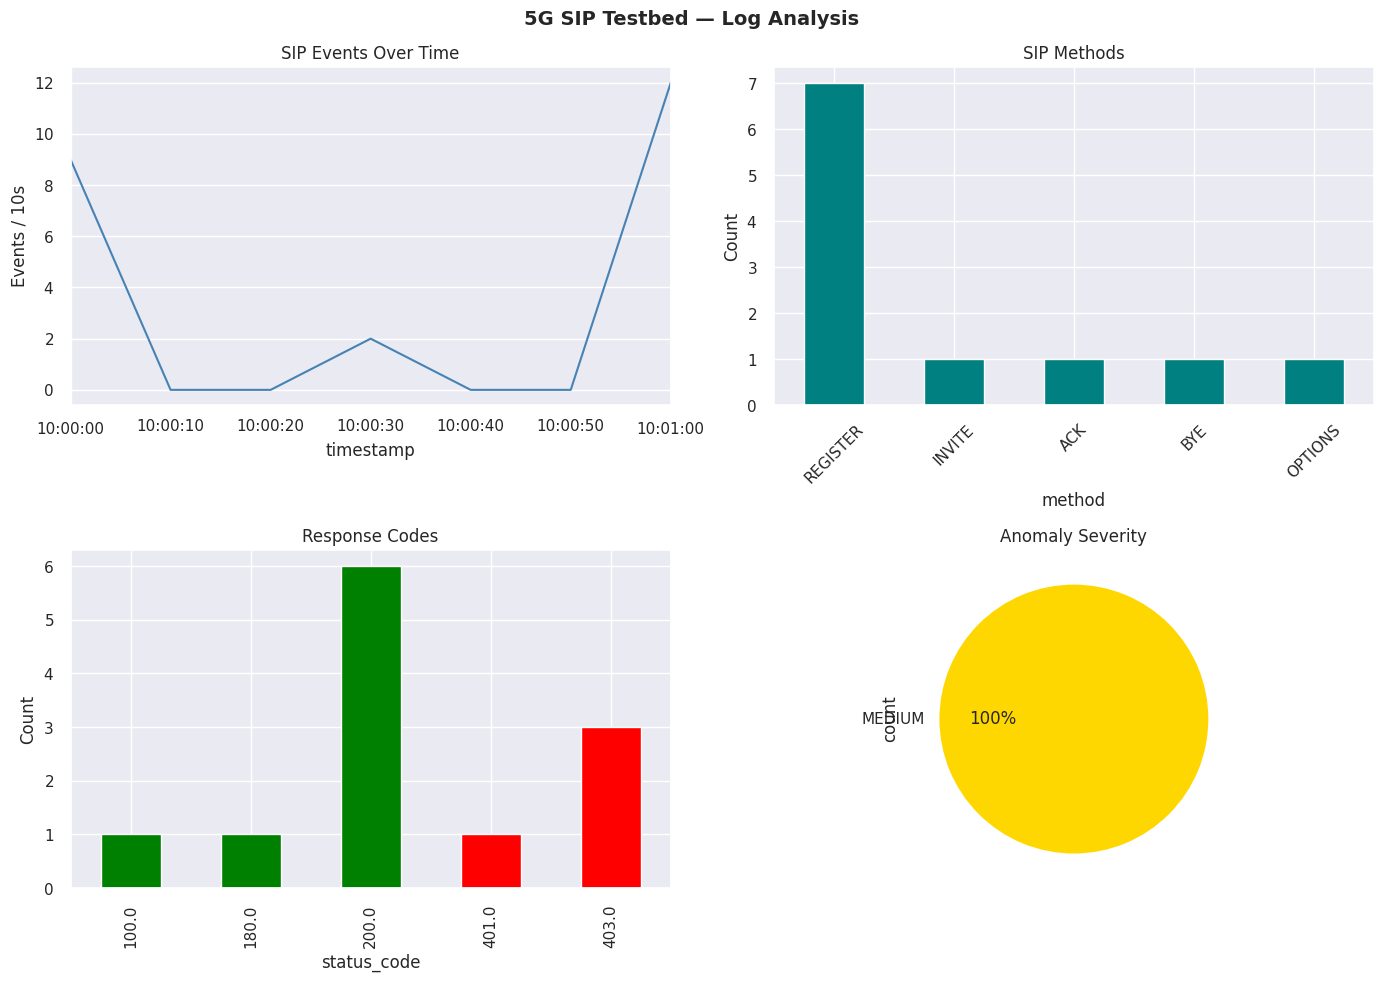

📊 Chart saved to sip_anomaly_report.png


In [159]:
if HAS_PLOT and df['timestamp'].notna().any():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('5G SIP Testbed — Log Analysis', fontsize=14, fontweight='bold')

    # 1. Events over time
    ax = axes[0, 0]
    ts_data = df.set_index('timestamp').resample('10s').size()
    ts_data.plot(ax=ax, color='steelblue')
    ax.set_title('SIP Events Over Time')
    ax.set_ylabel('Events / 10s')

    # 2. Method distribution
    ax = axes[0, 1]
    methods = df[df['type'] == 'request']['method'].value_counts()
    methods.plot(kind='bar', ax=ax, color='teal')
    ax.set_title('SIP Methods')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

    # 3. Response codes
    ax = axes[1, 0]
    if not responses.empty:
        codes = responses['status_code'].value_counts().sort_index()
        colors = ['green' if c < 300 else 'orange' if c < 400 else 'red' for c in codes.index]
        codes.plot(kind='bar', ax=ax, color=colors)
    ax.set_title('Response Codes')
    ax.set_ylabel('Count')

    # 4. Anomaly severity
    ax = axes[1, 1]
    if not report.empty:
        sev_counts = report['severity'].value_counts()
        colors_map = {'CRITICAL': 'red', 'HIGH': 'orange', 'MEDIUM': 'gold', 'LOW': 'skyblue'}
        sev_counts.plot(kind='pie', ax=ax, colors=[colors_map.get(s, 'gray') for s in sev_counts.index],
                        autopct='%1.0f%%')
        ax.set_title('Anomaly Severity')
    else:
        ax.text(0.5, 0.5, 'No Anomalies ✅', ha='center', va='center', fontsize=14)
        ax.set_title('Anomaly Severity')

    plt.tight_layout()
    plt.savefig('sip_anomaly_report.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("📊 Chart saved to sip_anomaly_report.png")
else:
    print("⚠️  Plotting unavailable (install matplotlib + seaborn)")


## 7. Configure your own

In [169]:
# === TESTBED CONFIGURATION ===
CONFIG = {
    # Known UE IPs (from UERANSIM tunnel subnet 10.45.0.0/16)
    'known_ues': ['10.45.0.2', '10.45.0.3'],

    # Kamailio server IP
    'sip_server': '10.10.0.1',

    # RTPengine IP
    'rtpengine': '10.10.0.30',

    # Thresholds
    'flood_threshold_rps': 10,      # requests/sec to flag as flood
    'reg_failure_threshold': 3,     # consecutive failures to flag
    'max_call_setup_sec': 10,       # max INVITE→ACK time

    # Log source
    'log_file': '/var/log/kamailio/kamailio.log',
    # Alternative: docker logs
    'docker_container': 'kamailio',
}

print("Config loaded. Modify values above for your environment.")
print(json.dumps(CONFIG, indent=2))


Config loaded. Modify values above for your environment.
{
  "known_ues": [
    "10.45.0.2",
    "10.45.0.3"
  ],
  "sip_server": "10.10.0.1",
  "rtpengine": "10.10.0.30",
  "flood_threshold_rps": 10,
  "reg_failure_threshold": 3,
  "max_call_setup_sec": 10,
  "log_file": "/var/log/kamailio/kamailio.log",
  "docker_container": "kamailio"
}


## 9. Model training

Beyond the rule-based detectors above, we train a lightweight **logistic-regression** classifier to *predict* problems rather than just flag them after the fact:

**Missing-ACK model** — predicts whether an `INVITE` will fail to complete (no `ACK`) from source reputation (known UE?), call-setup delay, and local congestion.



In [179]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

KNOWN_UES = {'10.45.0.2', '10.45.0.3'}  # legitimate testbed UEs (Alice, Bob)


def _extract_ip(raw):
    m = re.search(r'from\s+(\d+\.\d+\.\d+\.\d+)', str(raw))
    return m.group(1) if m else None


# ---------- Feature builder (works on real parsed logs) ----------
def invite_features(df, ack_window_sec=10):
    """One row per INVITE: features + actual missing-ACK label."""
    events = df.sort_values('timestamp').reset_index(drop=True)
    reqs = events[events['type'] == 'request']
    rows = []
    invites = events[(events['type'] == 'request') & (events['method'] == 'INVITE')]
    for _, inv in invites.iterrows():
        src = _extract_ip(inv['raw'])
        ts = inv['timestamp']
        later_acks = events[(events['type'] == 'request') & (events['method'] == 'ACK')
                            & (events['timestamp'] > ts)]
        if not later_acks.empty:
            setup_delay = (later_acks.iloc[0]['timestamp'] - ts).total_seconds()
            missing = int(setup_delay > ack_window_sec)
        else:
            setup_delay = float(ack_window_sec)  # no ACK seen -> treat as at threshold
            missing = 1
        # congestion proxy: requests in the surrounding 2s window
        if pd.notna(ts):
            near = reqs[(reqs['timestamp'] >= ts - pd.Timedelta('1s'))
                        & (reqs['timestamp'] <= ts + pd.Timedelta('1s'))]
            congestion = len(near)
        else:
            congestion = 0
        rows.append({
            'src_ip': src,
            'timestamp': ts,
            'is_known_ue': int(src in KNOWN_UES),
            'setup_delay_s': round(setup_delay, 3),
            'congestion': congestion,
            'actual_missing_ack': missing,
        })
    return pd.DataFrame(rows)


# ---------- Synthetic training corpus (encodes testbed dynamics) ----------
def _synth_invites(n=800, seed=7):
    rng = np.random.default_rng(seed)
    is_known = rng.integers(0, 2, n)
    setup_delay = rng.gamma(2.0, 2.5, n)
    congestion = rng.integers(1, 12, n)
    logit = -2.0 - 1.2 * is_known + 0.35 * setup_delay + 0.25 * congestion
    p = 1 / (1 + np.exp(-logit))
    missing = (rng.random(n) < p).astype(int)
    X = pd.DataFrame({'is_known_ue': is_known, 'setup_delay_s': setup_delay, 'congestion': congestion})
    return X, missing


def _train_and_report(name, X, y):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
    model = LogisticRegression(max_iter=1000)
    model.fit(Xtr, ytr)
    proba = model.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)
    print(f"=== {name} ===")
    print(f"  test accuracy : {accuracy_score(yte, pred):.3f}")
    print(f"  test ROC-AUC  : {roc_auc_score(yte, proba):.3f}")
    print("  coefficients  :", {f: round(c, 3) for f, c in zip(X.columns, model.coef_[0])})
    print()
    return model


ack_model = _train_and_report("Missing-ACK model", *_synth_invites())
print("✅ Predictive model trained")


=== Missing-ACK model ===
  test accuracy : 0.745
  test ROC-AUC  : 0.801
  coefficients  : {'is_known_ue': np.float64(-1.366), 'setup_delay_s': np.float64(0.413), 'congestion': np.float64(0.238)}

✅ Predictive model trained


In [189]:
# === Score the current parsed log ===
inv_df = invite_features(df)
if not inv_df.empty:
    Xi = inv_df[['is_known_ue', 'setup_delay_s', 'congestion']]
    inv_df['pred_missing_ack_prob'] = ack_model.predict_proba(Xi)[:, 1].round(3)
    inv_df['predicted_missing_ack'] = (inv_df['pred_missing_ack_prob'] >= 0.5).astype(int)
    print("🔮 Missing-ACK predictions:\n")
    cols = ['timestamp', 'src_ip', 'is_known_ue', 'setup_delay_s', 'congestion',
            'pred_missing_ack_prob', 'predicted_missing_ack', 'actual_missing_ack']
    print(inv_df[cols].to_string(index=False))
else:
    print("No INVITE requests in current log.")


🔮 Missing-ACK predictions:

              timestamp    src_ip  is_known_ue  setup_delay_s  congestion  pred_missing_ack_prob  predicted_missing_ack  actual_missing_ack
2026-07-18 10:00:05.200 10.45.0.2            1           1.85           1                  0.073                      0                   0
